In [ ]:
"""
Here, I try out an inference on wiener process data with an added 'glitch' in the data,
a very short but high-amplitude spike.
"""

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import nifty8 as ift

In [4]:
def wiener_process(n_steps, scale=1,dt=1.0):
    dW = np.random.normal(scale=np.sqrt(dt), size=n_steps)
    W = np.cumsum(dW)
    return scale*W

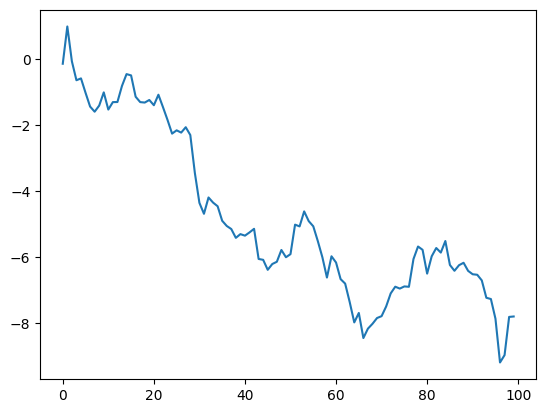

In [5]:
wp = wiener_process(100, scale=0.5)
plt.plot(wp)

In [12]:
(t0, t_max) = (0, 1)
n_pix = 2000
t = ift.RGSpace(shape=(n_pix, ), distances=t_max/2000)
t_val = np.linspace(t0, t_max, n_pix)

In [15]:
noise_config = {
    "fluctuations": (1,0.2),
    "loglogavgslope": (1, 1),
    "asperity": None,
    "flexibility": None,
    "offset_mean": 0,
    "offset_std": (1e-16, 1e-16),
}

n = ift.SimpleCorrelatedField(t, **noise_config)

In [16]:
cf_part = n(ift.from_random(n.domain))

0.30985458996876825 ;
-0.03998410624049553 ;
-36.826598198383586 ;
[-0.77935418 -0.52678519 -0.41995265 ... -0.02379792  0.4027408
 -0.15642366] ;


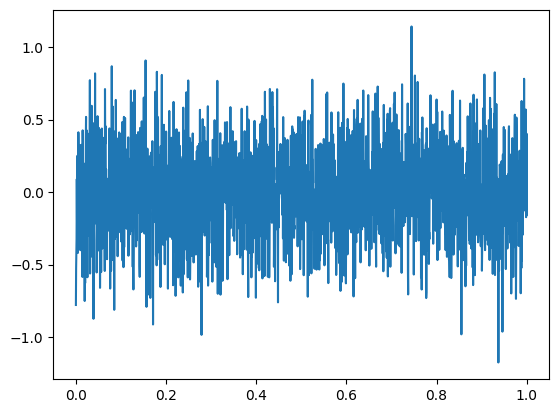

In [17]:
plt.plot(t_val, cf_part.val)

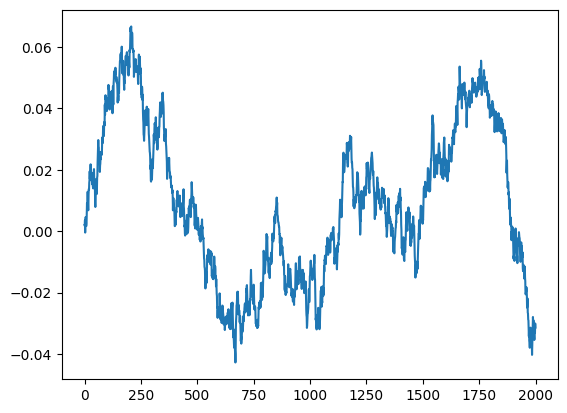

In [30]:
wp_part = wiener_process(n_pix, scale=0.1, dt=t_max/n_pix)
plt.plot(wp_part)

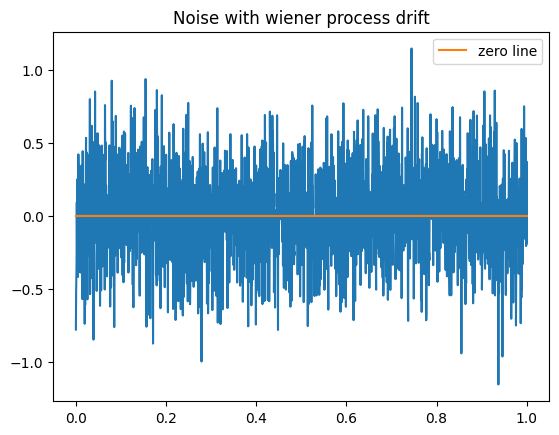

In [31]:
plt.title("Noise with wiener process drift")
plt.plot(t_val, wp_part + cf_part.val)
plt.plot(t_val, np.zeros_like(t_val), label="zero line")
plt.legend()

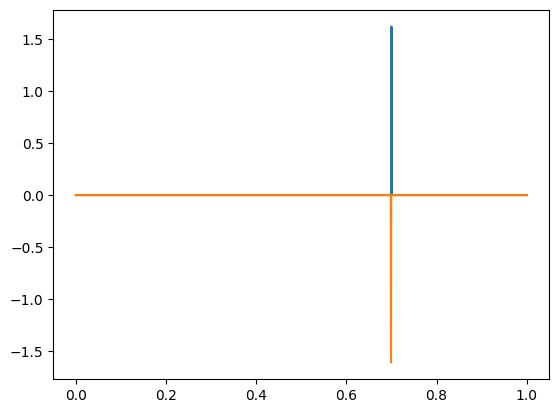

In [51]:
def gauss_peak(x, width, pos, scale=1):
    return scale*np.exp(-1/2 * ((x-pos)**2)/width**2)

scale = 5

glitch_part_plus = gauss_peak(x=t_val, pos=0.7, width=0.0001, scale=scale)
glitch_part_minus = -gauss_peak(x=t_val, pos=0.699, width=0.0001, scale=scale)
plt.plot(t_val, glitch_part_plus)
plt.plot(t_val, glitch_part_minus)

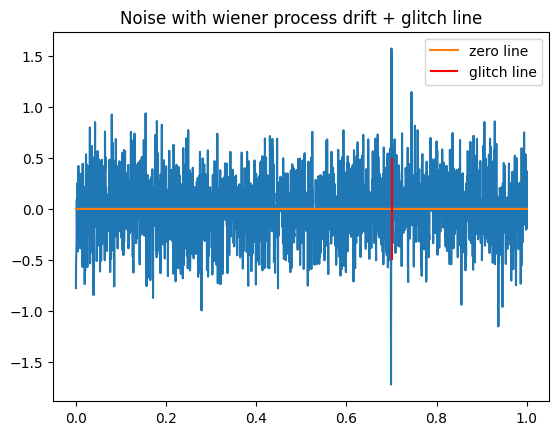

In [54]:
plt.title("Noise with wiener process drift + glitch line")
plt.plot(t_val, wp_part + cf_part.val + glitch_part_plus + glitch_part_minus)
plt.plot(t_val, np.zeros_like(t_val), label="zero line")
plt.vlines(0.7, -0.5, 0.5, label="glitch line", color="red")
plt.legend()

Now let's try out this weird non-stationary field idea

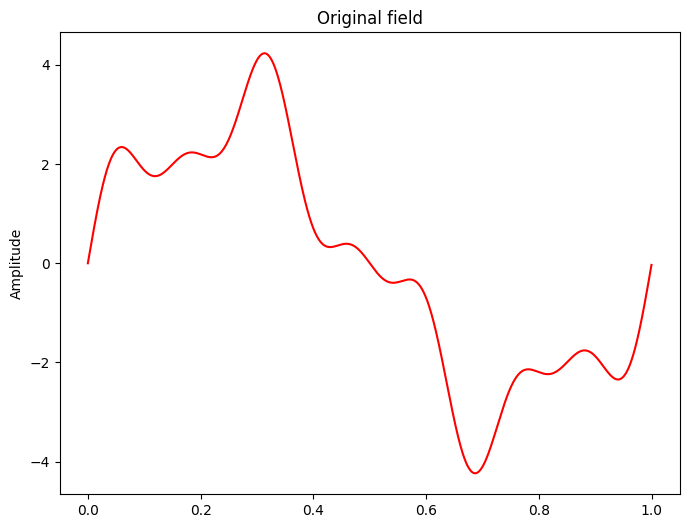

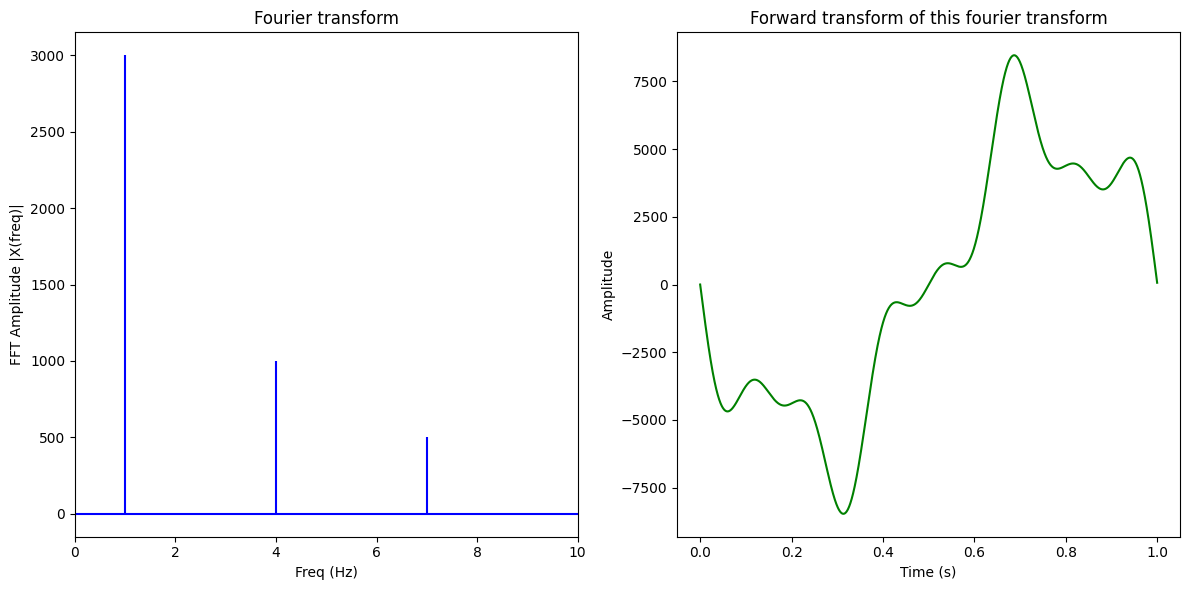

In [64]:
# sampling rate
sr = 2000
# sampling interval
ts = 1.0/sr
t = np.arange(0,1,ts)

freq = 1.
x = 3*np.sin(2*np.pi*freq*t)

freq = 4
x += np.sin(2*np.pi*freq*t)

freq = 7
x += 0.5* np.sin(2*np.pi*freq*t)

plt.figure(figsize = (8, 6))
plt.title("Original field")
plt.plot(t, x, 'r')
plt.ylabel('Amplitude')

plt.show()

from numpy.fft import fft, ifft

X = fft(x)
N = len(X)
n = np.arange(N)
T = N/sr
freq = n/T

plt.figure(figsize = (12, 6))
plt.subplot(121)
plt.title("Fourier transform")

plt.stem(freq, np.abs(X), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.xlim(0, 10)

plt.subplot(122)
plt.title("Forward transform of this fourier transform")
plt.plot(t, fft(X), 'g')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

In [65]:
ns_config = {
    "fluctuations": (1,0.2),
    "loglogavgslope": (-4, 1),
    "asperity": None,
    "flexibility": None,
    "offset_mean": 0,
    "offset_std": (1e-16, 1e-16),
}

ns_model = ift.SimpleNonStationaryField(t, **ns_config)